In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [13]:
df=pd.read_csv('../Algerian_forest_fires_dataset_Clean.csv')

In [14]:
df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [15]:
df.columns

Index(['Unnamed: 0', 'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain',
       'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [16]:
df.drop(['day','month','year','Unnamed: 0'],axis=1,inplace=True)


In [17]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [18]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [19]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [20]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [21]:
X=df.drop('FWI',axis=1)
Y=df['FWI']

In [22]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [23]:
Y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [25]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [26]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

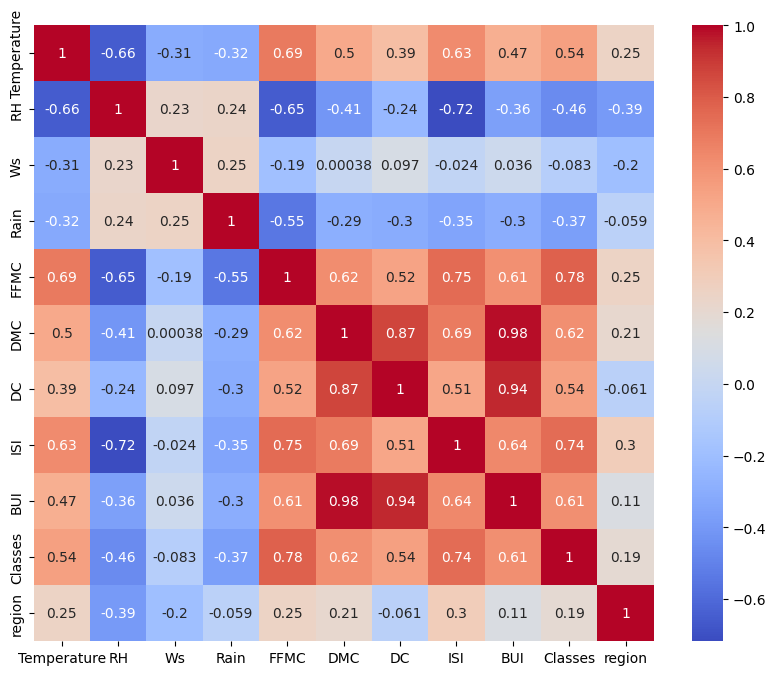

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(),annot=True,cmap='coolwarm')

In [28]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [29]:
correlation(X_train,0.8)#threshold value is 0.9 setup by expert

{'BUI', 'DC'}

In [30]:
df.drop(['BUI','DC'],axis=1,inplace=True)

In [31]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,1.3,0.5,0,0
1,29,61,13,1.3,64.4,4.1,1.0,0.4,0,0
2,26,82,22,13.1,47.1,2.5,0.3,0.1,0,0
3,25,89,13,2.5,28.6,1.3,0.0,0.0,0,0
4,27,77,16,0.0,64.8,3.0,1.2,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,4.5,6.5,1,1
239,28,87,15,4.4,41.1,6.5,0.1,0.0,0,1
240,27,87,29,0.5,45.9,3.5,0.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,1.7,0.7,0,1


In [32]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [33]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.77269802,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.90344718,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  0.38339978,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.03419633,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.18383528,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.99290713,
        -1.10431526, -0.98907071]], shape=(182, 11))

In [34]:
X_test_scaled

array([[-3.01758418e-01,  1.15223531e-01, -2.19053977e-01,
        -3.84060174e-01,  6.33218240e-01, -4.25075679e-02,
         2.91560671e-01,  2.03772218e-01,  1.01256865e-01,
         9.05538514e-01, -9.89070710e-01],
       [ 2.39325642e-01, -5.52632606e-01, -9.78441098e-01,
        -3.84060174e-01,  7.37980727e-01, -3.83352062e-01,
        -3.97206667e-01,  3.65823283e-01, -4.07976691e-01,
         9.05538514e-01, -9.89070710e-01],
       [-1.11338451e+00, -2.85490151e-01,  9.20026704e-01,
         6.45241658e-01, -9.73139891e-01, -9.14435344e-01,
        -8.52248151e-01, -8.37984627e-01, -9.30973317e-01,
        -1.10431526e+00,  1.01105006e+00],
       [ 5.09867672e-01, -2.85490151e-01, -9.78441098e-01,
        -2.90487280e-01,  1.30358303e-01,  3.14190159e-01,
         7.92106304e-01, -6.29633258e-01,  5.21030473e-01,
        -1.10431526e+00,  1.01105006e+00],
       [-5.72300448e-01,  1.82009145e-01, -5.98747538e-01,
        -3.84060174e-01,  5.42424085e-01,  1.00171523e-01,
  

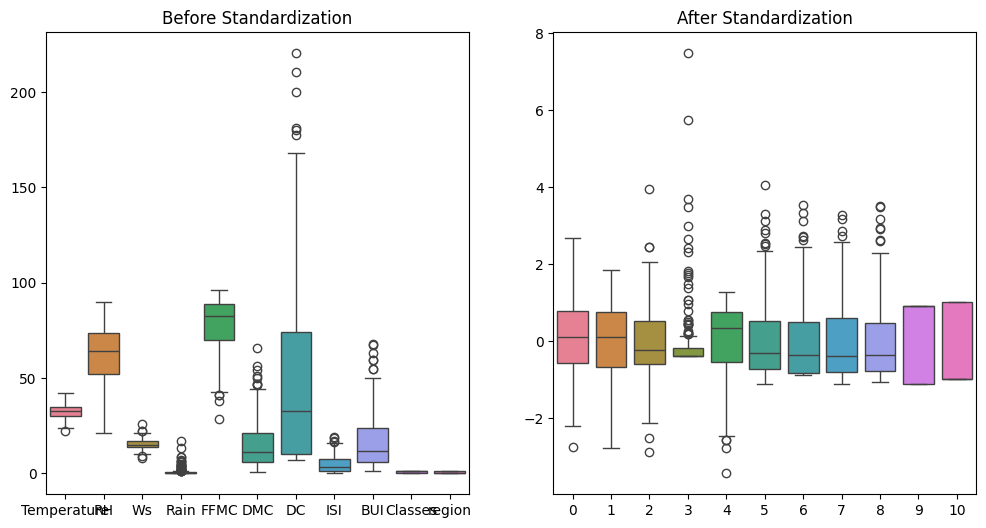

In [35]:
plt.subplots(1,2,figsize=(12,6))
sns.boxplot(data=X_train,ax=plt.subplot(1,2,1))
plt.title('Before Standardization')
sns.boxplot(data=X_train_scaled,ax=plt.subplot(1,2,2))
plt.title('After Standardization')
plt.show()

In [36]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)


Mean Squared Error: 0.469824357168851
R-squared: 0.9893850294922101


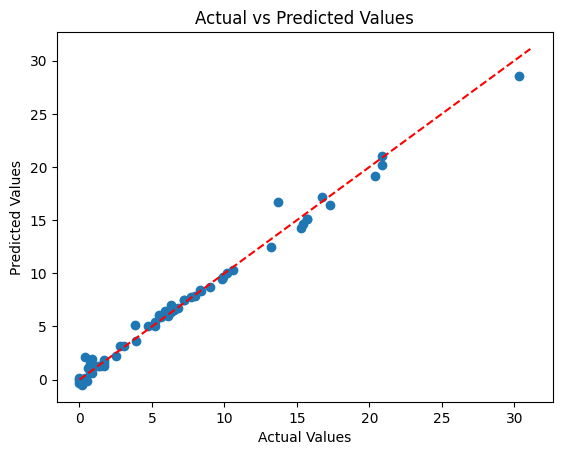

In [37]:
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

Mean Squared Error: 2.0000583482892274
R-squared: 0.9548117077009715


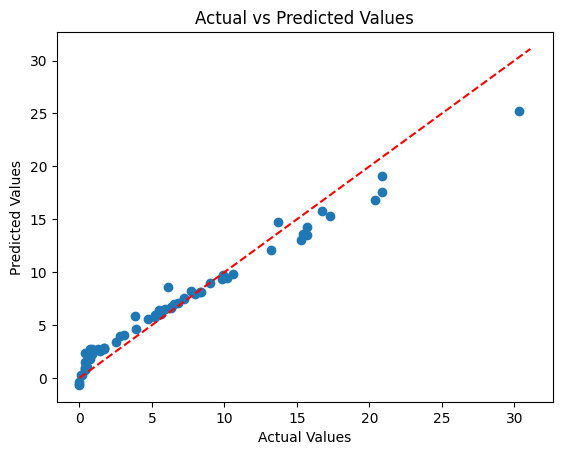

In [38]:
#ridge and lasso
from sklearn.linear_model import Lasso
model=Lasso()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

Mean Squared Error: 0.5677317795293473
R-squared: 0.987172959417527


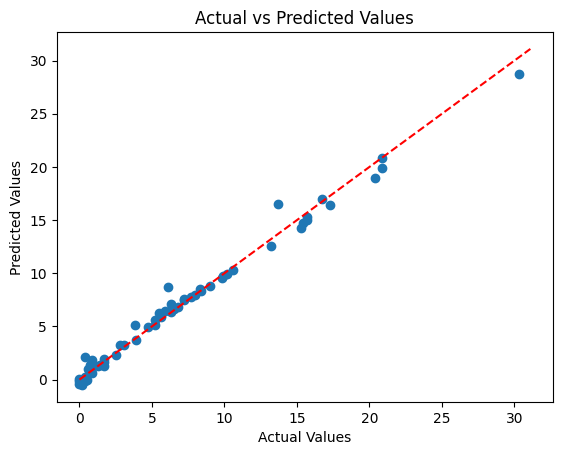

In [39]:
#ridge and lasso
from sklearn.linear_model import Ridge
model=Ridge()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

Mean Squared Error: 4.396320516000339
R-squared: 0.900671789556956


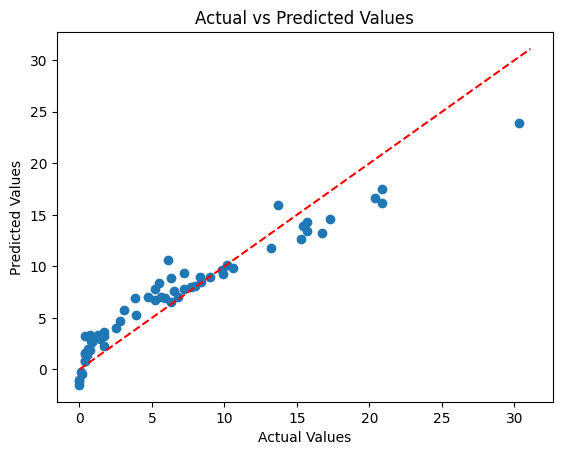

In [40]:
#ridge and lasso
from sklearn.linear_model import ElasticNet
model=ElasticNet()
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

In [41]:
from sklearn.linear_model import LassoCV
lasso_cv=LassoCV()


Mean Squared Error: 0.5820671051401517
R-squared: 0.9868490744246432


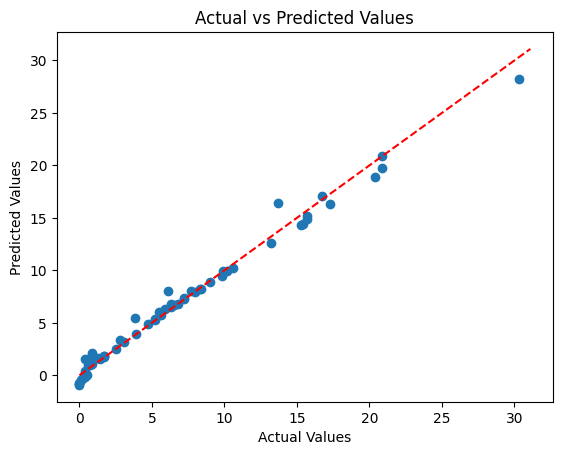

In [42]:
#ridge and lasso
from sklearn.linear_model import LassoCV
model=LassoCV(cv=5)
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

In [43]:
model.alpha_

np.float64(0.06139149443725231)

In [44]:
model.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [45]:
model.mse_path_

array([[54.04680834, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139504, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.19961097, 14.9991189 ,  9.9

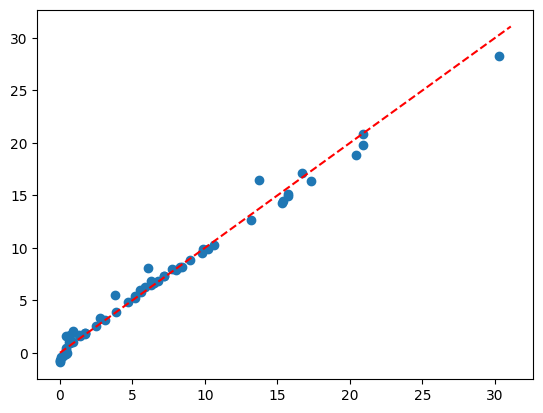

In [46]:
y_pred=model.predict(X_test_scaled)
plt.scatter(Y_test,y_pred)
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')

Mean Squared Error: 0.5677317795293473
R-squared: 0.987172959417527


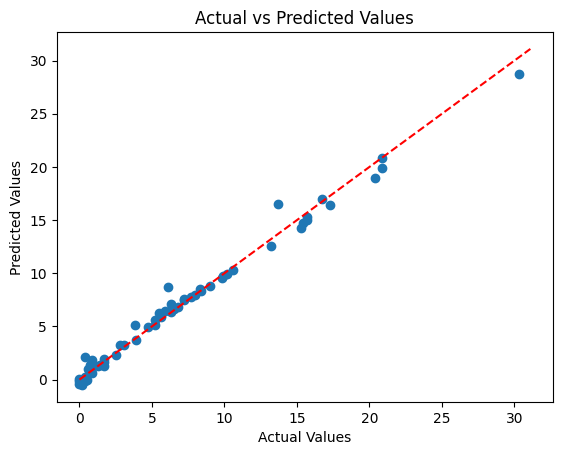

In [47]:
#ridge and lasso
from sklearn.linear_model import RidgeCV
model=RidgeCV(cv=5)
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

In [48]:
model.alphas

(0.1, 1.0, 10.0)

Mean Squared Error: 0.7369662999119067
R-squared: 0.9833493614806597


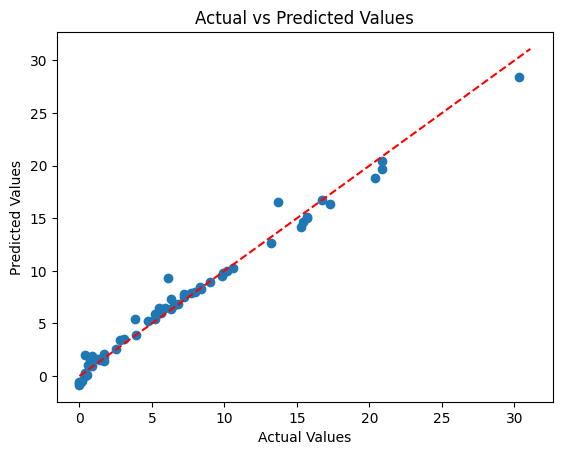

In [49]:
#ridge and lasso
from sklearn.linear_model import ElasticNetCV
model=ElasticNetCV(cv=5)
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

In [50]:
model.alpha_

np.float64(0.04622700712786237)

In [51]:
model.alphas

'warn'

In [52]:
model.l1_ratio_

np.float64(0.5)

Mean Squared Error: 0.7369662999119067
R-squared: 0.9833493614806597


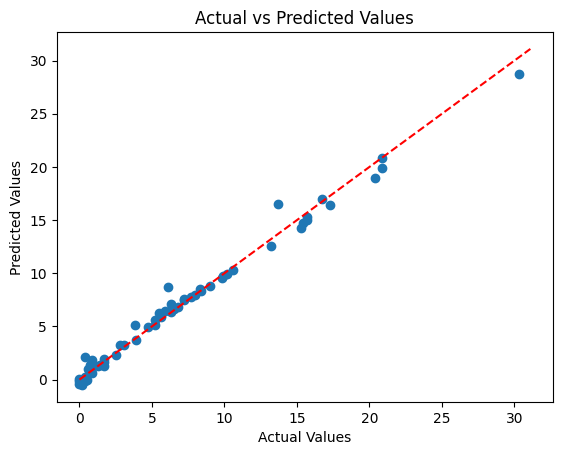

In [53]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,Y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print('Mean Squared Error:',mse)
print('R-squared:',r2)
plt.scatter(Y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()],'r--')
plt.title('Actual vs Predicted Values')
plt.show()

In [54]:
#pickle the preprocessing and ml models
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [55]:
StandardScaler

sklearn.preprocessing._data.StandardScaler

In [56]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridgr.pkl','wb'))

In [57]:
print(X_train.columns.tolist())

['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'Classes', 'region']
